# **👔 E-Com Biz Transactions EDA**
E-commerce has become a new channel to support businesses development. Through e-commerce, businesses can get access and establish a wider market presence by providing cheaper and more efficient distribution channels for their products or services. This is a sales transaction data set of UK-based e-commerce (online retail) for one year. This London-based shop has been selling gifts and homewares for adults and children through the website since 2007. Their customers come from all over the world and usually make direct purchases for themselves. There are also small businesses that buy in bulk and sell to other customers through retail outlet channels.

The data set contains 500K rows and 8 columns. The following is the description of each column.


1. TransactionNo (categorical): a six-digit unique number that defines each transaction. The letter “C” in the code indicates a cancellation.
2. Date (numeric): the date when each transaction was generated.
3. ProductNo (categorical): a five or six-digit unique character used to identify a specific product.
4. Product (categorical): product/item name.
5. Price (numeric): the price of each product per unit in pound sterling (£).
6. Quantity (numeric): the quantity of each product per transaction. Negative values related to cancelled transactions.
7. CustomerNo (categorical): a five-digit unique number that defines each customer.
8. Country (categorical): name of the country where the customer resides.

## **🥅 Dataset Exploration and Learning Goals (Investor POV Outlook)**
#### **1. Customer Concentration & Quality Analysis**
High customer concentration is a massive risk for SMEs. If a few wholesale buyers make up 80% of revenue, the business is incredibly fragile. Segment customers into "Retail" (low quantity, high frequency) vs. "SME Bulk Buyers" (high quantity, low frequency). Calculate the percentage of total revenue generated by the top 1%, 5%, and 10% of customers.

#### **2. Revenue Quality & Churn DNA**
Investors pay a premium for predictable, recurring revenue. You need to distinguish between stable repeat buyers and one-off holiday shoppers. Cohort analysis based on the month of the customer's first purchase. Track how spending behavior evolves over the 12-month period for each cohort. Deep-dive into the cancellation rate (transactions starting with "C" or negative quantities). Does a specific country or product category have a disproportionately high return/cancellation rate? (High returns drag down EBITDA margins due to reverse logistics costs).


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
from matplotlib import pyplot as plt
import plotly.express as px

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/gabrielramos87/an-online-shop-business/Sales Transaction v.4a.csv


In [2]:
sales_data = pd.read_csv('/kaggle/input/datasets/gabrielramos87/an-online-shop-business/Sales Transaction v.4a.csv')
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionNo  536350 non-null  object 
 1   Date           536350 non-null  object 
 2   ProductNo      536350 non-null  object 
 3   ProductName    536350 non-null  object 
 4   Price          536350 non-null  float64
 5   Quantity       536350 non-null  int64  
 6   CustomerNo     536295 non-null  float64
 7   Country        536350 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.7+ MB


In [3]:
sales_data.head(10)

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom
5,581475,12/9/2019,21705,Bag 500g Swirly Marbles,10.65,24,13069.0,United Kingdom
6,581475,12/9/2019,22118,Joy Wooden Block Letters,11.53,18,13069.0,United Kingdom
7,581475,12/9/2019,22119,Peace Wooden Block Letters,12.25,12,13069.0,United Kingdom
8,581475,12/9/2019,22217,T-Light Holder Hanging Lace,10.65,12,13069.0,United Kingdom
9,581475,12/9/2019,22216,T-Light Holder White Lace,10.55,24,13069.0,United Kingdom


In [4]:
sales_data['ProductName'].value_counts()

ProductName
Cream Hanging Heart T-Light Holder     2378
Regency Cakestand 3 Tier               2200
Jumbo Bag Red Retrospot                2159
Party Bunting                          1727
Lunch Bag Red Retrospot                1639
                                       ... 
Pink Polkadot Kids Bag                    1
Pink Large Jeweled Photoframe             1
Assorted Tutti Frutti Round Box           1
Pink Marshmallow Scarf Knitting Kit       1
Porcelain Hanging Bell Small              1
Name: count, Length: 3768, dtype: int64

In [5]:
sales_data['Country'].value_counts()

Country
United Kingdom          485095
Germany                  10675
France                   10526
EIRE                      8048
Belgium                   2539
Spain                     2430
Switzerland               2336
Netherlands               2330
Portugal                  1848
Australia                 1704
Norway                     938
Austria                    887
Iceland                    787
Finland                    692
Italy                      661
Channel Islands            629
Cyprus                     582
Unspecified                447
Sweden                     417
Denmark                    416
USA                        379
Japan                      371
Israel                     358
Singapore                  215
Poland                     174
Hong Kong                  153
Canada                     150
Malta                      149
Greece                      67
United Arab Emirates        67
European Community          58
RSA                         57


In [6]:
sales_data.isnull().sum()

TransactionNo     0
Date              0
ProductNo         0
ProductName       0
Price             0
Quantity          0
CustomerNo       55
Country           0
dtype: int64

In [7]:
sales_data = sales_data.dropna(subset=['CustomerNo'])

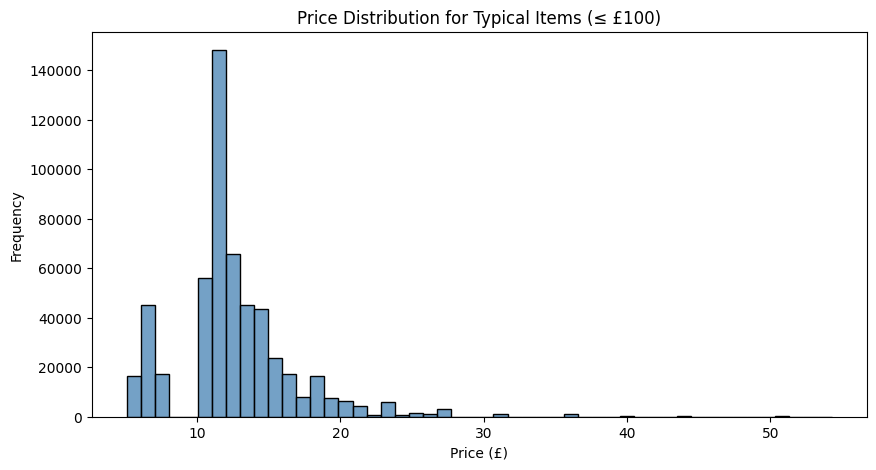

In [8]:
typical_prices = sales_data[sales_data['Price'] <= 60]

plt.figure(figsize=(10, 5))
sns.histplot(data=typical_prices, x='Price', bins=50, color='steelblue')

plt.title('Price Distribution for Typical Items (≤ £100)')
plt.xlabel('Price (£)')
plt.ylabel('Frequency')
plt.show()

# **Dataset Introduction & EDA**
The data set contains 500K rows and 8 columns. The following is the description of each column.

1. TransactionNo (categorical): a six-digit unique number that defines each transaction. The letter “C” in the code indicates a cancellation.
2. Date (numeric): the date when each transaction was generated.
3. ProductNo (categorical): a five or six-digit unique character used to identify a specific product.
4. Product (categorical): product/item name.
5. Price (numeric): the price of each product per unit in pound sterling (£).
6. Quantity (numeric): the quantity of each product per transaction. Negative values related to cancelled transactions.
7. CustomerNo (categorical): a five-digit unique number that defines each customer.
8. Country (categorical): name of the country where the customer resides.


## **Categorical Columns & Price Distribution**
There are a lot of different products that are sold by the e-commerce shop, the most popular being these four :
| Product Description | Quantity / Count |
| --- | --- |
| Cream Hanging Heart T-Light Holder | 2378 |
| Regency Cakestand 3 Tier | 2200 |
| Jumbo Bag Red Retrospot | 2159 |
| Party Bunting | 1727 |
| Lunch Bag Red Retrospot | 1639 |

and some products were only sold once such as :
| Product Description | Quantity / Count |
| --- | --- |
| Pink Polkadot Kids Bag | 1 |
| Pink Large Jeweled Photoframe | 1 |
| Assorted Tutti Frutti Round Box | 1 |
| Pink Marshmallow Scarf Knitting Kit | 1 |
| Porcelain Hanging Bell Small | 1 |

Prices usually vary in the 2 distinct ranges : 5.13-18.24 & 18.24-31.35

Sales data showcases that majority buyers are located in United kingdom and European countries, but the business has reached customers over 200-450+ in many different countries and regions such as middle east and asia. While 447 customers were labelled 'unspecified' and 58 customers were classified in the 'European Community'

In [9]:
data = sales_data['Country'].value_counts().reset_index()

data['Log_Count'] = np.log10(data['count'])

# Plot a global choropleth
fig = px.choropleth(
    data, 
    locations="Country", 
    locationmode="country names",
    color="Log_Count", 
    hover_name="Country",
    hover_data={"count": True, "Log_Count": False}, 
    color_continuous_scale=px.colors.sequential.Plasma,
    title="Global Customer Concentration (Log Scale)",
    projection="natural earth" # Fixes the stretching
)

# Center the title
fig.update_layout(
    title_x=0.5
)

fig.show()

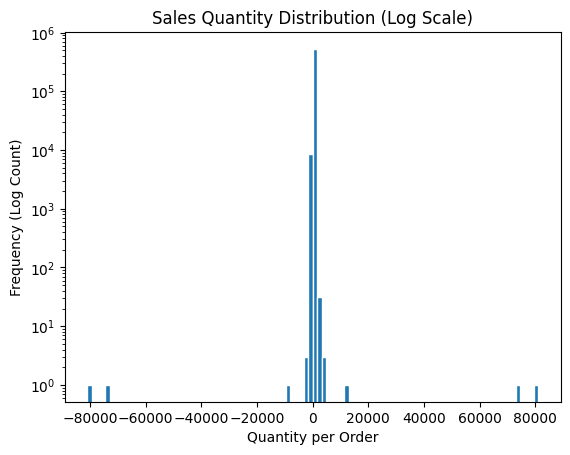

In [10]:
sales_data['Quantity'].plot(kind='hist', bins=100, log=True, edgecolor='white')

plt.title('Sales Quantity Distribution (Log Scale)')
plt.xlabel('Quantity per Order')
plt.ylabel('Frequency (Log Count)')
plt.show()

## **Customer Concentration & Quality** 

In [11]:
sales_data['Revenue'] = sales_data['Quantity'] * sales_data['Price']
# Separate positive transactions for the concentration analysis
df_pos = sales_data[sales_data['Quantity'] > 0].copy()

# Aggregate by customer
customer_profile = df_pos.groupby('CustomerNo').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Order_Frequency=('TransactionNo', 'nunique')
).reset_index()

# Calculate Average Quantity per Order to capture the "Bulk" nature
customer_profile['Avg_Qty_Per_Order'] = customer_profile['Total_Quantity'] / customer_profile['Order_Frequency']

In [12]:
# Sort customers by revenue descending
customer_profile = customer_profile.sort_values(by='Total_Revenue', ascending=False)
total_company_revenue = customer_profile['Total_Revenue'].sum()

# Calculate concentration percentiles
for p in [1, 5, 10]:
    top_n_count = int(np.ceil(len(customer_profile) * (p / 100)))
    top_n_revenue = customer_profile['Total_Revenue'].head(top_n_count).sum()
    pct_contribution = (top_n_revenue / total_company_revenue) * 100
    print(f"Top {p}% of customers ({top_n_count} clients) account for {pct_contribution:.2f}% of total revenue.")

Top 1% of customers (48 clients) account for 29.92% of total revenue.
Top 5% of customers (236 clients) account for 47.67% of total revenue.
Top 10% of customers (472 clients) account for 58.97% of total revenue.


In [13]:
med_freq = customer_profile['Order_Frequency'].median()
med_qty = customer_profile['Avg_Qty_Per_Order'].median()

def assign_investor_segment(row):
    if row['Avg_Qty_Per_Order'] >= med_qty and row['Order_Frequency'] < med_freq:
        return 'SME Bulk Buyer'
    elif row['Avg_Qty_Per_Order'] < med_qty and row['Order_Frequency'] >= med_freq:
        return 'Retail'
    elif row['Avg_Qty_Per_Order'] >= med_qty and row['Order_Frequency'] >= med_freq:
        return 'High-Value Key Account'
    else:
        return 'Low-Value Occasional'

customer_profile['Investor_Segment'] = customer_profile.apply(assign_investor_segment, axis=1)

In [14]:
customer_profile.head(10)

,CustomerNo,Total_Revenue,Total_Quantity,Order_Frequency,Avg_Qty_Per_Order,Investor_Segment
1880,14646.0,2112282.03,197420,73,2704.383562,High-Value Key Account
3302,16446.0,1002741.57,80997,2,40498.500000,High-Value Key Account
2085,14911.0,914633.52,80383,198,405.974747,High-Value Key Account
126,12415.0,900545.54,77669,20,3883.450000,High-Value Key Account
4581,18102.0,897137.36,64124,60,1068.733333,High-Value Key Account
4082,17450.0,891438.53,69993,46,1521.586957,High-Value Key Account
68,12346.0,840113.80,74215,1,74215.000000,SME Bulk Buyer
1506,14156.0,694965.02,57845,54,1071.203704,High-Value Key Account
1140,13694.0,646116.78,63860,51,1252.156863,High-Value Key Account
4127,17511.0,639006.19,64549,31,2082.225806,High-Value Key Account


In [15]:
customer_profile['Investor_Segment'].value_counts(normalize=True) * 100

Investor_Segment
High-Value Key Account    35.714286
Retail                    30.860534
Low-Value Occasional      19.139466
SME Bulk Buyer            14.285714
Name: proportion, dtype: float64

## **Revenue Quality & Churn Statistics**

In [16]:
# Flag cancellations
sales_data['Is_Cancellation'] = (sales_data['Quantity'] < 0) | (sales_data['TransactionNo'].astype(str).str.startswith('C'))

# Overall Company Cancellation Rate (by transaction volume and value)
total_canceled_value = sales_data[sales_data['Is_Cancellation']]['Revenue'].abs().sum()
gross_positive_revenue = sales_data[sales_data['Quantity'] > 0]['Revenue'].sum()
leakage_pct = (total_canceled_value / gross_positive_revenue) * 100
print(f"Revenue Leakage via Cancellations: {leakage_pct:.2f}% of Gross Revenue")

# Risk breakdown by Country
country_returns = sales_data.groupby('Country').agg(
    Gross_Rev=('Revenue', lambda x: x[x > 0].sum()),
    Canceled_Rev=('Revenue', lambda x: x[x < 0].abs().sum())
)
country_returns['Return_Rate_Pct'] = (country_returns['Canceled_Rev'] / country_returns['Gross_Rev']) * 100

Revenue Leakage via Cancellations: 4.24% of Gross Revenue


In [17]:
country_returns.sort_values(by='Return_Rate_Pct', ascending=False).head(5)

,Gross_Rev,Canceled_Rev,Return_Rate_Pct
Country,,,
USA,32868.65,15418.27,46.908741
Czech Republic,7674.44,917.64,11.957094
Saudi Arabia,969.50,66.35,6.843734
Spain,281012.27,15273.47,5.435161
United Kingdom,52524576.47,2512715.42,4.783885


# **Conclusion & Validation**

*The Thesis:* Based on the notebook's study of this dataset and business evaluation, the business has a variety of customer profiles with 35.7% high value key accounts, 30% retail buyers, 19% occasional buyers and 14.3% bulk buyers. This diverse range of consumers allows the business to drive revenue from different types of customers. The business also showcased high diversity of consumers from all over the world with United kingdom being the most frequent customer followed by other European countries such as Germany and France as illustrated in image_272858.png.

*The Risk:* Further data analysis reveals structural fragilities regarding customer concentration and operational inefficiencies. As demonstrated in image_272835.png, the top 1% of customers (just 48 clients) command **29.92%** of the total revenue, while the top 10% dictate **58.97%**, creating a high-dependence vulnerability. Furthermore, international expansion comes with substantial margin drag; image_2727fc.png reveals a severe operational bottleneck in the USA market, which suffers from an alarming **46.91% return rate**. This revenue leakage via cancellations threatens to severely compress EBITDA margins due to reverse logistics overhead.

*The Verdict:* While the business exhibits healthy baseline demand and excellent market penetration across the UK and Europe, an investor must approach the current valuation with caution. Prior to any acquisition or capital deployment, due diligence must prioritize auditing the USA distribution framework to mitigate high returns and implementing retention strategies to de-risk the top 1% client concentration. Resolving these operational leaks will transform volatile revenue into a predictable, premium-multiple cash flow machine.